# 07. Backtest: TGN Anomaly-Triggered ERC Rebalancing

투자금 1억 원, 2018-01 ~, 편도 거래비용 10bp. 평상시에는 매주 Equal Risk Contribution(ERC)으로 리밸런싱하고, TGN attention 기반 이상 신호가 뜨면 위험 전이 점수가 높은 자산을 제외한 방어 포트폴리오로 전환합니다. `Miss-n` 변형은 노드의 방향 예측이 n일 연속 틀리면 이상으로 간주하는 추가 규칙입니다.


In [ ]:
%pip install -q yfinance torch-geometric

📁 로컬 폴더(./Find-A final_data)에서 CSV 데이터를 로드합니다...
📈 yfinance에서 [투자 대상 7종]의 가격 데이터만 다운로드합니다...


[*********************100%***********************]  7 of 7 completed


🧠 로컬 폴더(./Find-A final_model)에서 TGN 모델 가중치를 로드합니다...
✅ TGN 가중치 로드 성공!

🚀 지정된 전략 조합에 대해 시뮬레이션을 시작합니다...
▶️ 테스트 진행 중: [Base TGN 2.0 (No Miss Logic)]


/opt/anaconda3/lib/python3.11/site-packages/scipy/optimize/_optimize.py:404: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "


▶️ 테스트 진행 중: [TGN 2.0 + Miss-2 + Wait-10d]
▶️ 테스트 진행 중: [TGN 2.0 + Miss-2 + Wait-20d]
▶️ 테스트 진행 중: [TGN 2.0 + Miss-2 + Wait-30d]
▶️ 테스트 진행 중: [TGN 2.0 + Miss-3 + Wait-10d]
▶️ 테스트 진행 중: [TGN 2.0 + Miss-3 + Wait-20d]
▶️ 테스트 진행 중: [TGN 2.0 + Miss-3 + Wait-30d]
▶️ 테스트 진행 중: [TGN 2.0 + Miss-4 + Wait-10d]
▶️ 테스트 진행 중: [TGN 2.0 + Miss-4 + Wait-20d]
▶️ 테스트 진행 중: [TGN 2.0 + Miss-4 + Wait-30d]
▶️ 테스트 진행 중: [TGN 2.0 + Miss-5 + Wait-10d]
▶️ 테스트 진행 중: [TGN 2.0 + Miss-5 + Wait-20d]
▶️ 테스트 진행 중: [TGN 2.0 + Miss-5 + Wait-30d]

✅ 모든 백테스트 종료!

전략 라벨                          |  최종자산(억) | CAGR(%) |  변동성(%) | Sharpe |  MDD(%) | 연 Turnover
-------------------------------------------------------------------------------------
Base TGN 2.0 (No Miss Logic)   |       2.43 |   11.36 |   14.07 |   0.83 |  -27.45 |       1.6
TGN 2.0 + Miss-2 + Wait-10d    |       0.53 |   -7.29 |   16.88 |  -0.37 |  -50.65 |     102.4
TGN 2.0 + Miss-2 + Wait-20d    |       0.53 |   -7.40 |   16.90 |  -0.37 |  -51.10 |     101.7
TGN

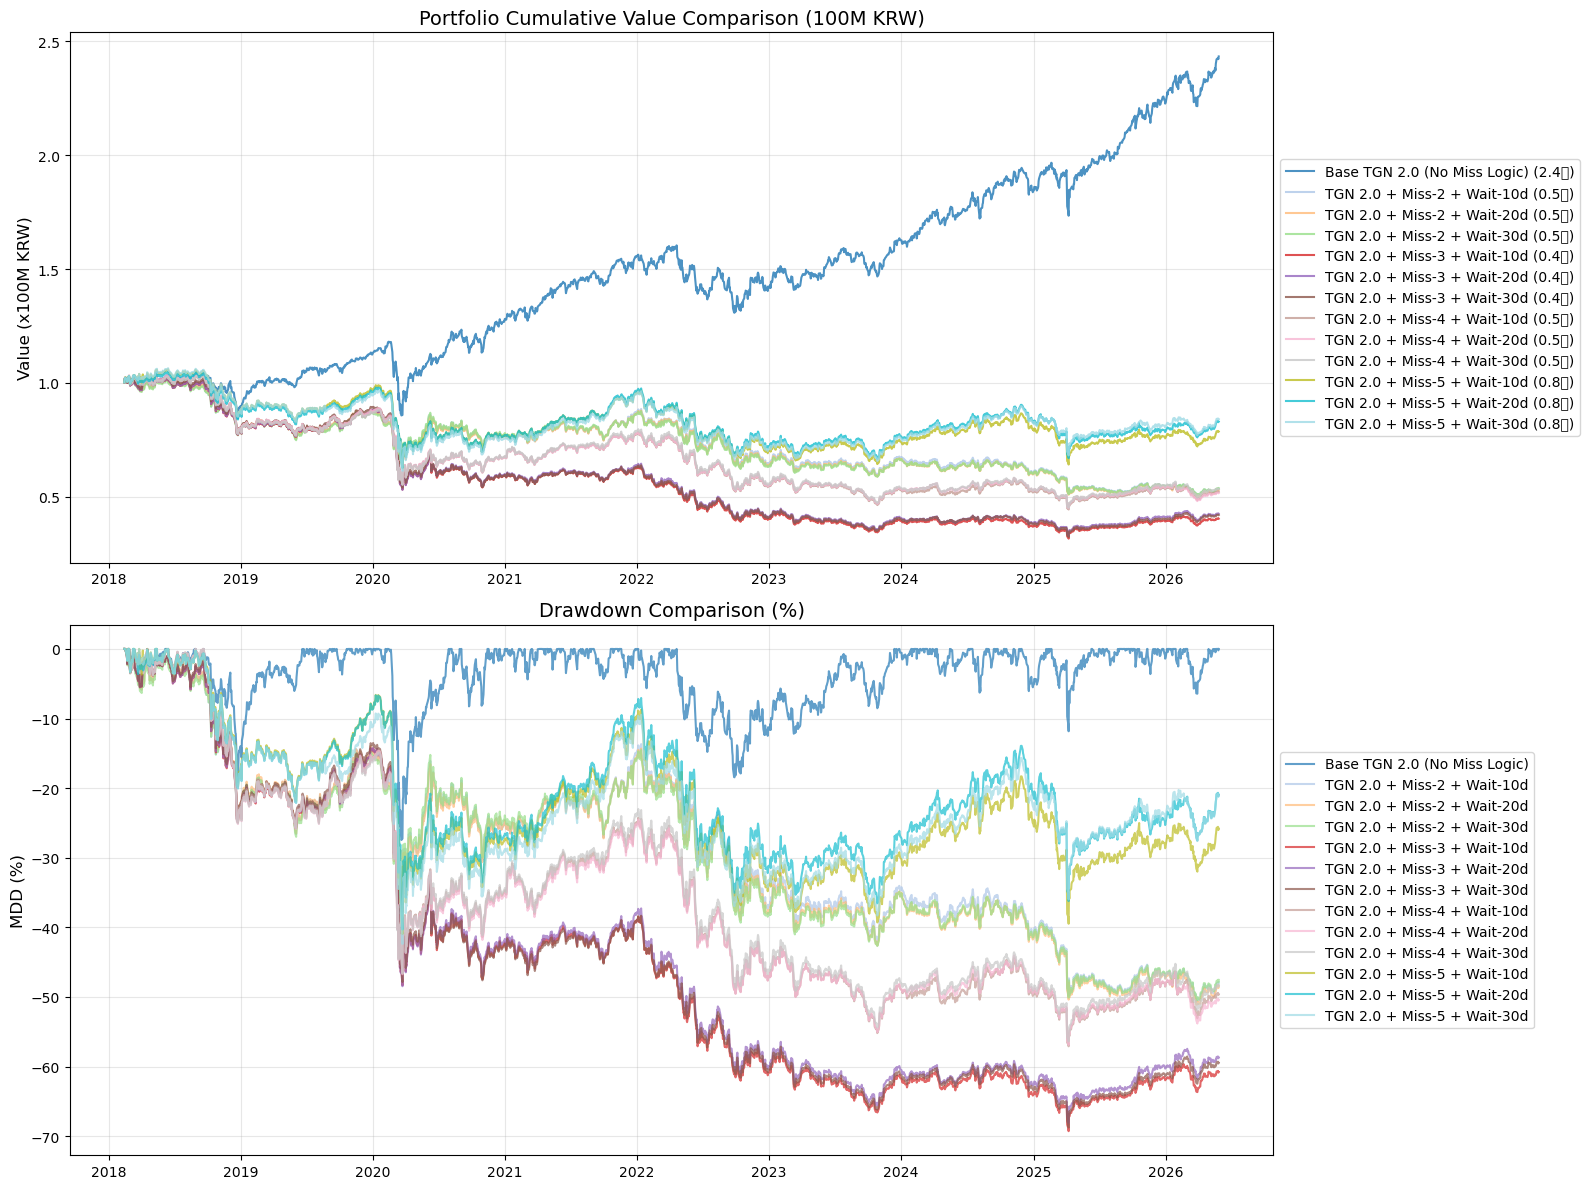

In [5]:
import os
import glob
import yfinance as yf
import numpy as np
import pandas as pd
import networkx as nx
import torch
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from torch.nn import Linear
from torch_geometric.nn.models.tgn import TGNMemory, IdentityMessage, LastAggregator
from torch_geometric.nn import TransformerConv
#from google.colab import drive

# ==========================================
# 0. 하이퍼파라미터 및 경로 설정
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
INIT_CAPITAL = 100_000_000
TEST_START = "2018-01-01"
COST_BPS = 10.0
COST_RATE = COST_BPS / 10000.0
ANN = 252

DATA_DIR = './Find-A final_data'     # 노드별 CSV 폴더
MODEL_DIR = './Find-A final_model'   # 03 노트북에서 저장한 best_*_all.pth

# TGN 파라미터
memory_dim = 100
time_dim = 100
msg_dim = 2
time_window = 30
rolling_window = 60
num_classes = 12
te_threshold = 0.001

VOL_TARGET = 0.10  # 연율 변동성 임계 10%

# ==========================================
# 💡 [핵심 1] 자산 및 요인(Factor) 분리 설정
# ==========================================
INVESTABLE_ASSETS = {
    'gold': 'GLD',
    'vnq': 'VNQ',
    'xlk': 'XLK',
    'xlf': 'XLF',
    'xlv': 'XLV',
    'xle': 'XLE',
    'xly': 'XLY'
}
YF_TICKERS = list(INVESTABLE_ASSETS.values())

PRICE_BASED_ASSETS = {
    'gold', 'vnq', 'xlk', 'xlf', 'xlv', 'xle', 'xly',
    'stoxx50', 'nikkei225', 'shanghai', 'hangseng',
    'oil_wti', 'natgas', 'silver', 'copper', 'corn', 'wheat', 'soybean', 'coffee', 'cotton'
}

# ==========================================
# 💡 [핵심 2] TGN + 리밸런싱 전략 테스트 셋 (방향 연속 틀림 조건 추가)
# ==========================================
PARAMS_TO_TEST = [
    # 기존 베이스라인 전략 (비교용)
    {"threshold": 2.0, "cooldown": 10, "rebal_strategy": "rp_time", "miss_n": 999, "label": "Base TGN 2.0 (No Miss Logic)"}
]

for n in [2, 3, 4, 5]:
    for cd in [10, 20, 30]:
        PARAMS_TO_TEST.append({
            "threshold": 2.0,            
            "cooldown": cd,              
            "rebal_strategy": "rp_time",
            "miss_n": n,                 
            "label": f"TGN 2.0 + Miss-{n} + Wait-{cd}d"
        })

# ==========================================
# 1. 포트폴리오 유틸 함수 및 TGN 클래스
# ==========================================
def port_ann_vol(w, cov):
    return float(np.sqrt(max(w @ cov @ w, 0.0)) * np.sqrt(ANN))

def erc_weights(cov):
    n = cov.shape[0]
    if n == 0: return np.array([])
    if n == 1: return np.array([1.0])
    w0 = np.ones(n) / n
    def obj(w):
        port_var = w @ cov @ w
        if port_var <= 0: return 0.0
        rc_frac = (w * (cov @ w)) / port_var
        return np.sum((rc_frac - 1.0 / n) ** 2)
    cons = ({"type": "eq", "fun": lambda w: np.sum(w) - 1.0},)
    bnds = tuple((1e-6, 1.0) for _ in range(n))
    res = minimize(obj, w0, method="SLSQP", bounds=bnds, constraints=cons, options={"maxiter": 1000, "ftol": 1e-14})
    w = np.clip(res.x, 0, None)
    return w / w.sum() if w.sum() > 0 else w0

def transfer_entropy(source, target, k=1):
    n = len(source)
    if n <= k: return 0.0
    joint_count = sum(1 for i in range(k, n) if source[i-1] == target[i])
    return joint_count / (n - k)

class GraphEmbedding(torch.nn.Module):
    def __init__(self, in_channels, out_channels, msg_dim, time_dim):
        super().__init__()
        self.time_enc = Linear(1, msg_dim)
        self.conv = TransformerConv(in_channels, out_channels // 2, heads=2, dropout=0.1, edge_dim=msg_dim)

    def forward(self, x, last_update, edge_index, t, msg):
        rel_t = (t - last_update[edge_index[0]]).float()
        rel_t_emb = self.time_enc(rel_t.view(-1, 1))
        edge_attr = msg + rel_t_emb
        return self.conv(x, edge_index, edge_attr, return_attention_weights=True)

class NodePredictor(torch.nn.Module):
    def __init__(self, embedding_dim, out_dim=12):
        super().__init__()
        self.lin1 = Linear(embedding_dim, embedding_dim // 2)
        self.lin2 = Linear(embedding_dim // 2, out_dim)

    def forward(self, target_node):
        return self.lin2(torch.relu(self.lin1(target_node)))

# ==========================================
# 2. 데이터 로드 및 전처리
# ==========================================
def load_data_and_models():
    # 💡 출력 문구를 코랩(드라이브) 대신 '로컬 폴더'로 명확하게 수정했습니다.
    print(f"📁 로컬 폴더({DATA_DIR})에서 CSV 데이터를 로드합니다...")
    csv_files = glob.glob(os.path.join(DATA_DIR, '**', '*.csv'), recursive=True)
    raw_data_dict = {}

    for file_path in csv_files:
        asset_name = os.path.splitext(os.path.basename(file_path))[0].lower()
        if asset_name == 'manifest': continue
        try:
            df = pd.read_csv(file_path)
            df.columns = df.columns.str.strip()
            rename_dict = {col: 'Date' for col in df.columns if col.lower() in ['date', '날짜', 'time']}
            df.rename(columns=rename_dict, inplace=True)
            if 'Date' in df.columns:
                raw_data_dict[asset_name] = df
        except Exception: pass

    if 'vkospi' in raw_data_dict:
        del raw_data_dict['vkospi']

    asset_names = list(raw_data_dict.keys())
    processed_data = {}
    
    for name in asset_names:
        df = raw_data_dict[name].copy()
        df['Date'] = pd.to_datetime(df['Date'])
        df = df.sort_values('Date').set_index('Date')

        target_col = df.columns[0]
        if df[target_col].min() >= 0 and df[target_col].mean() > 1.0:
            df['Log_Return'] = np.log(df[target_col] / df[target_col].shift(1))
        else:
            df['Log_Return'] = df[target_col]

        df['rolling_mean'] = df['Log_Return'].rolling(window=rolling_window).mean()
        df['rolling_std'] = df['Log_Return'].rolling(window=rolling_window).std()
        df['scaled_value'] = (df['Log_Return'] - df['rolling_mean']) / (df['rolling_std'] + 1e-8)
        df = df.dropna()

        raw_class = np.floor(df['scaled_value'])
        df['target_class'] = (raw_class.clip(-6, 5) + 6).astype(int)
        mask = (df.index >= pd.Timestamp(TEST_START))
        processed_data[name] = df[mask]

    all_dates = set()
    for df in processed_data.values():
        all_dates.update(df.index)
    global_calendar = pd.Series(list(all_dates)).sort_values().reset_index(drop=True)

    print("📈 yfinance에서 [투자 대상 7종]의 가격 데이터만 다운로드합니다...")
    yf_df = yf.download(YF_TICKERS, start="2016-01-01", auto_adjust=False)['Close']
    yf_returns = yf_df.pct_change().dropna(how='all').fillna(0)
    valid_dates = yf_returns.index.intersection(global_calendar)
    valid_dates = valid_dates[valid_dates >= pd.Timestamp(TEST_START)]

    # 💡 모델 가중치를 불러오는 폴더 위치도 명확하게 출력되도록 수정했습니다.
    print(f"🧠 로컬 폴더({MODEL_DIR})에서 TGN 모델 가중치를 로드합니다...")
    num_asset = len(asset_names)
    memory = TGNMemory(num_nodes=num_asset, raw_msg_dim=msg_dim, memory_dim=memory_dim, time_dim=time_dim,
                       message_module=IdentityMessage(msg_dim, memory_dim, time_dim), aggregator_module=LastAggregator()).to(device)
    gnn = GraphEmbedding(memory_dim, memory_dim, msg_dim, time_dim).to(device)
    predictor = NodePredictor(embedding_dim=memory_dim, out_dim=num_classes).to(device)

    try:
        memory.load_state_dict(torch.load(os.path.join(MODEL_DIR, 'best_memory_all.pth'), map_location=device))
        gnn.load_state_dict(torch.load(os.path.join(MODEL_DIR, 'best_gnn_all.pth'), map_location=device))
        predictor.load_state_dict(torch.load(os.path.join(MODEL_DIR, 'best_predictor_all.pth'), map_location=device))
        print("✅ TGN 가중치 로드 성공!")
    except Exception as e:
        print(f"⚠️ 가중치 로드 실패: {e}")
        return None

    memory.eval(); gnn.eval(); predictor.eval()
    return global_calendar, processed_data, asset_names, yf_returns, valid_dates, (memory, gnn, predictor)


# ==========================================
# 3. 단일 파라미터 시뮬레이션 엔진
# ==========================================
def run_single_simulation(params, data_bundle):
    target_threshold = params.get('threshold', 999.0)
    target_cooldown = params['cooldown']
    rebal_strategy = params['rebal_strategy']
    miss_n = params.get('miss_n', 999) # 💡 연속 방향 틀림 기준 파라미터

    global_calendar, processed_data, asset_names, yf_returns, valid_dates, models = data_bundle
    memory, gnn, predictor = models

    num_asset = len(asset_names)
    all_nodes_tensor = torch.arange(num_asset, dtype=torch.long).to(device)

    V = float(INIT_CAPITAL)
    n_investable = len(YF_TICKERS)
    w = np.ones(n_investable) / n_investable

    values = []
    simulated_dates = []
    total_turnover = 0.0
    prev_week = None
    defensive_state = False
    defensive_days_left = 0
    bins = [-1.0, 1.0]
    
    # 💡 방향 검증을 위한 상태 저장소
    consecutive_misses = {} 
    prev_predictions = {}   

    with torch.no_grad():
        memory.reset_state()

        for t_idx in range(time_window, len(global_calendar) - 1):
            current_date = global_calendar[t_idx]
            next_date = global_calendar[t_idx + 1]
            if current_date not in valid_dates: continue

            # 1. 일일 수익률 반영
            r = yf_returns.loc[current_date].values
            port_r = float(w @ r)
            V *= (1.0 + port_r)
            w = w * (1.0 + r)
            w = w / w.sum()

            values.append(V)
            simulated_dates.append(current_date)

            iso = current_date.isocalendar()
            week_key = (iso[0], iso[1])
            is_week_first = (week_key != prev_week)
            prev_week = week_key

            active_nodes = [i for i, name in enumerate(asset_names) if current_date in processed_data[name].index and not pd.isna(processed_data[name].loc[current_date, 'scaled_value'])]
            
            # 💡 [추가 로직] 전일 모델의 상승/하락 예측이 오늘 실제 결과와 맞았는지 평가
            for node in active_nodes:
                if node in prev_predictions:
                    name = asset_names[node]
                    # 실제 수익률 방향 (0 이상이면 상승)
                    actual_up = processed_data[name].loc[current_date, 'Log_Return'] >= 0.0
                    # 전일 예측 방향 (클래스 6 이상이면 상승)
                    pred_up = prev_predictions[node] >= 6
                    
                    if actual_up != pred_up:
                        consecutive_misses[node] = consecutive_misses.get(node, 0) + 1
                    else:
                        consecutive_misses[node] = 0 # 맞추면 카운트 초기화

            if not active_nodes: continue

            # 3. 그래프 피처 업데이트
            edge_sources, edge_targets, edge_features = [], [], []
            for i in active_nodes:
                name_i = asset_names[i]
                current_return = processed_data[name_i].loc[current_date, 'scaled_value']
                edge_sources.append(i); edge_targets.append(i); edge_features.append([current_return, 1.0])
                data_i = processed_data[name_i].loc[:current_date, 'scaled_value'].tail(time_window).values

                for j in active_nodes:
                    if i == j: continue
                    name_j = asset_names[j]
                    data_j = processed_data[name_j].loc[:current_date, 'scaled_value'].tail(time_window).values

                    if len(data_i) == time_window and len(data_j) == time_window:
                        te_value = transfer_entropy(np.digitize(data_i, bins), np.digitize(data_j, bins), k=1)
                        if te_value >= te_threshold:
                            edge_sources.append(i); edge_targets.append(j); edge_features.append([current_return, te_value])

            if not edge_sources: continue

            edge_index = torch.tensor([edge_sources, edge_targets], dtype=torch.long).to(device)
            edge_attr = torch.tensor(edge_features, dtype=torch.float).to(device)

            valid_nodes, targets = [], []
            for node in active_nodes:
                name = asset_names[node]
                if next_date in processed_data[name].index:
                    targets.append(processed_data[name].loc[next_date, 'target_class'])
                    valid_nodes.append(node)
            if not valid_nodes: continue

            # 4. TGN 예측 수행
            t_tensor = torch.full((edge_index.size(1),), t_idx, dtype=torch.long).to(device)
            z_emb, last_update = memory(all_nodes_tensor)
            h, (attn_edges, attn_weights) = gnn(z_emb, last_update, edge_index, t_tensor, edge_attr)
            
            logits = predictor(h[valid_nodes])
            preds = logits.argmax(dim=1)
            # 💡 [추가 로직] 다음 날 평가를 위해 현재의 노드별 예측값 저장
            prev_predictions = {node: preds[idx].item() for idx, node in enumerate(valid_nodes)}
            
            memory.update_state(edge_index[0], edge_index[1], t_tensor, edge_attr)

            # =======================================================
            # 5. 이상 감지 로직 (연속 틀림 조건 + 어텐션 조건 통합)
            # =======================================================
            anomaly_triggered = False
            anomaly_node_idx_global = None

            # (A) 방향을 연속 n번 틀린 노드가 있는지 우선 확인
            for node in valid_nodes:
                if consecutive_misses.get(node, 0) >= miss_n:
                    anomaly_triggered = True
                    anomaly_node_idx_global = node
                    break

            # (B) 방향 틀림으로 안 걸렸다면 기존 어텐션 기반 위험도 체크
            if not anomaly_triggered and attn_edges is not None and attn_edges.size(1) > 0:
                e_np = attn_edges.cpu().numpy()
                w_np = attn_weights.mean(dim=1).cpu().numpy() if attn_weights.dim() > 1 else attn_weights.cpu().numpy()

                node_attention_scores = {node: 0.0 for node in valid_nodes}
                for i in range(e_np.shape[1]):
                    dst = e_np[1, i]
                    if dst in node_attention_scores:
                        node_attention_scores[dst] += w_np[i]

                for node in valid_nodes:
                    name = asset_names[node]
                    score = node_attention_scores[node]

                    if score >= target_threshold:
                        if name in PRICE_BASED_ASSETS:
                            is_price_dropping = processed_data[name].loc[current_date, 'Log_Return'] < 0.0
                            if is_price_dropping:
                                anomaly_triggered = True
                                anomaly_node_idx_global = node
                                break
                        else:
                            anomaly_triggered = True
                            anomaly_node_idx_global = node
                            break

            hist = yf_returns.loc[:current_date].tail(rolling_window)
            cov = hist.cov().values if len(hist) >= rolling_window else np.eye(n_investable)
            target_w = None

            # 이상 상황(Anomaly)이 감지되어 방어 모드 진입
            if anomaly_triggered and attn_edges is not None:
                e_np = attn_edges.cpu().numpy()
                w_np = attn_weights.mean(dim=1).cpu().numpy() if attn_weights.dim() > 1 else attn_weights.cpu().numpy()
                
                G = nx.DiGraph()
                for i in range(e_np.shape[1]):
                    G.add_edge(e_np[0, i], e_np[1, i], weight=w_np[i])

                closeness = nx.closeness_centrality(G, distance='weight')
                scores = np.zeros(n_investable)
                for i, local_name in enumerate(INVESTABLE_ASSETS.keys()):
                    node_id = asset_names.index(local_name)
                    if G.has_edge(anomaly_node_idx_global, node_id):
                        scores[i] = G[anomaly_node_idx_global][node_id]['weight']
                    else:
                        scores[i] = closeness.get(node_id, 0.0) * np.mean(w_np)

                threshold_score = np.median(scores)
                valid_idx = np.where(scores < threshold_score)[0]

                if len(valid_idx) > 0:
                    sub_cov = cov[np.ix_(valid_idx, valid_idx)]
                    sub_w = erc_weights(sub_cov)
                    target_w = np.zeros(n_investable)
                    target_w[valid_idx] = sub_w
                else:
                    target_w = erc_weights(cov)

                defensive_state = True
                defensive_days_left = target_cooldown

            # 평상시 모드
            else:
                if defensive_state:
                    defensive_days_left -= 1
                    if defensive_days_left <= 0:
                        target_w = erc_weights(cov)
                        defensive_state = False
                else:
                    cur_vol = port_ann_vol(w, cov)
                    do_rebal = False
                    
                    if rebal_strategy == "rp_time":
                        do_rebal = is_week_first
                    elif rebal_strategy == "rp_thresh":
                        do_rebal = (cur_vol > VOL_TARGET)
                    elif rebal_strategy == "rp_tt":
                        do_rebal = is_week_first or (cur_vol > VOL_TARGET)
                        
                    if do_rebal:
                        target_w = erc_weights(cov)

            # 비중 업데이트
            if target_w is not None:
                trade_vol = np.abs(target_w - w).sum()
                total_turnover += 0.5 * trade_vol
                V *= (1.0 - COST_RATE * trade_vol)
                w = target_w

    return pd.Series(values, index=simulated_dates), total_turnover

# ==========================================
# 4. 통합 실행
# ==========================================
def run_simulations():
    data_bundle = load_data_and_models()
    if data_bundle is None: return None

    results = {}
    print("\n🚀 지정된 전략 조합에 대해 시뮬레이션을 시작합니다...")

    for params in PARAMS_TO_TEST:
        print(f"▶️ 테스트 진행 중: [{params['label']}]")
        vser, turn = run_single_simulation(params, data_bundle)
        results[params['label']] = {'vser': vser, 'turnover': turn}

    print("\n✅ 모든 백테스트 종료!")
    return results

# ==========================================
# 5. 성과 지표 출력 및 시각화
# ==========================================
def print_and_plot_metrics(results):
    if not results: return

    fig, axes = plt.subplots(2, 1, figsize=(16, 12))
    colors = plt.cm.tab20(np.linspace(0, 1, len(results))) # 색상 팔레트 확장 (항목이 많으므로)

    print("\n" + "="*85)
    print(f"{'전략 라벨':<30} | {'최종자산(억)':>8} | {'CAGR(%)':>7} | {'변동성(%)':>7} | {'Sharpe':>6} | {'MDD(%)':>7} | {'연 Turnover':>9}")
    print("-" * 85)

    for idx, (label, res) in enumerate(results.items()):
        vser = res['vser']
        turnover = res['turnover']
        rser = vser.pct_change().dropna()
        years = len(vser) / ANN

        final_value_eok = vser.iloc[-1] / 1e8
        cagr = ((vser.iloc[-1] / INIT_CAPITAL) ** (1 / years) - 1) * 100
        ann_vol = rser.std() * np.sqrt(ANN) * 100
        sharpe = (rser.mean() / rser.std() * np.sqrt(ANN)) if rser.std() > 0 else 0
        mdd = (vser / vser.cummax() - 1).min() * 100
        ann_turnover = turnover / years

        print(f"{label:<30} | {final_value_eok:>10.2f} | {cagr:>7.2f} | {ann_vol:>7.2f} | {sharpe:>6.2f} | {mdd:>7.2f} | {ann_turnover:>9.1f}")

        c = colors[idx]
        axes[0].plot(vser.index, vser / 1e8, label=f"{label} ({final_value_eok:.2f} x100M)", color=c, alpha=0.8)
        axes[1].plot(vser.index, (vser / vser.cummax() - 1) * 100, label=label, color=c, alpha=0.7)

    print("="*85 + "\n")

    axes[0].set_title("Portfolio Cumulative Value Comparison (100M KRW)", fontsize=14)
    axes[0].set_ylabel("Value (x100M KRW)", fontsize=12)
    axes[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))
    axes[0].grid(alpha=0.3)

    axes[1].set_title("Drawdown Comparison (%)", fontsize=14)
    axes[1].set_ylabel("MDD (%)", fontsize=12)
    axes[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('./backtest_result.png', dpi=300, bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    # 💡 로컬 환경이므로 구글 드라이브 마운트 코드를 주석 처리(또는 삭제)합니다.
    # drive.mount('/content/drive')

    # 1. 시뮬레이션 계산 (이 함수 내부에서 로컬 폴더의 데이터를 읽어옵니다)
    saved_results = run_simulations()

    # 2. 결과 출력
    print_and_plot_metrics(saved_results)